# AG-CNN — Comparativa E1-E5 (MobileNetV2 vs EfficientNet vs Random Search vs Default)
Notebook unico que corre todos los experimentos y deja los resultados listos para comparar.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import keras
import torch

import ag_core as ag
from ag_core import HyperParams, Individual

print(f"GPU disponible: {'Si' if torch.cuda.is_available() else 'No'}")

GPU disponible: Si


## 1. Configuracion global (compartida entre ambos backbones)

In [3]:
SEED = 29
N_PER_CLASS = 200
DIR_DATASET = Path("data/PlantVillage")
SPLIT = (0.70, 0.15, 0.15)

CLASS_NAMES = sorted([d.name for d in DIR_DATASET.iterdir() if d.is_dir()])
N_CLASS = len(CLASS_NAMES)

# Backbones a comparar (E3): agregar/quitar aqui sin tocar nada mas
BACKBONES = ["MobileNetV2", "EfficientNetB0"]

ag.configure(
    models={
        "MobileNetV2": {
            "fn": keras.applications.MobileNetV2,
            "preprocess": keras.applications.mobilenet_v2.preprocess_input,
        },
        "EfficientNetB0": {
            "fn": keras.applications.EfficientNetB0,
            "preprocess": keras.applications.efficientnet.preprocess_input,
        },
    },
    n_class=N_CLASS,
    seed=SEED,
    pop_size=10,
    gen_max=8,
    gen_pat=3,
    epochs_fitness=5,
    epochs_testeo=20,
)

## 2. Carga y division del dataset (una sola vez, se reusa para ambos backbones)

In [4]:
def load_images(data_dir):
    X, y = [], []
    for idx, cname in enumerate(CLASS_NAMES):
        files = sorted((data_dir / cname).glob("*.JPG"))
        if len(files) > N_PER_CLASS:
            files = random.sample(files, N_PER_CLASS)
        for p in files:
            img = Image.open(p).convert("RGB").resize((224, 224))
            X.append(np.asarray(img, dtype=np.uint8))
            y.append(idx)
    return np.array(X), np.array(y)

X_raw, y_all = load_images(DIR_DATASET)

train_frac, valid_frac, test_frac = SPLIT
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_all, test_size=(test_frac + valid_frac), stratify=y_all, random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=test_frac/(test_frac + valid_frac), stratify=y_temp, random_state=SEED,
)

cw = compute_class_weight("balanced", classes=np.arange(N_CLASS), y=y_train)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(cw)}

fit_data = dict(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, class_weight=CLASS_WEIGHT)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (386, 224, 224, 3)  Val: (83, 224, 224, 3)  Test: (83, 224, 224, 3)


In [29]:
# Pruba de fitness para ver que el tiempo de ejecución por iteración
import time
ag.clear_fitness_cache()
t0 = time.time()
ag.get_fitness("MobileNetV2", HyperParams(0.001, 32, "adam", 0.2), **fit_data)
print(f"Una evaluacion de fitness tomo {time.time()-t0:.1f}s")

alpha=1.00e-03 batch=32 phi=adam rho=0.20 | F1=0.9667  t=  9.3s
Una evaluacion de fitness tomo 9.8s


In [15]:
print("N_CLASS:", N_CLASS)
print("CLASS_NAMES:", CLASS_NAMES)

for cname in CLASS_NAMES:
    n_files = len(list((DIR_DATASET / cname).glob("*.JPG")))
    print(f"{cname:30s} -> {n_files} archivos")

N_CLASS: 3
CLASS_NAMES: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Potato___Early_blight          -> 1000 archivos
Potato___Late_blight           -> 1000 archivos
Potato___healthy               -> 152 archivos


In [16]:
# 1. Verificar que no haya archivos duplicados/casi-duplicados entre splits
import hashlib

def file_hash(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()

# si guardaste las rutas de archivos al cargar, compara hashes train vs test

train_hashes = {hash(x.tobytes()) for x in X_train}
test_hashes = {hash(x.tobytes()) for x in X_test}
print("Duplicados exactos train/test:", len(train_hashes & test_hashes))

Duplicados exactos train/test: 0


## 3. E1/E2 — Loop principal: Default, AG y Random Search para cada backbone
El cache de fitness (ag_core.FITNESS_CACHE) evita reentrenar cromosomas repetidos dentro de un mismo backbone.

In [13]:
all_results = {}   # backbone -> dict con todo lo relevante para E3/E4/E5

for BACKBONE in BACKBONES:
    print("\n" + "="*70)
    print(f"BACKBONE: {BACKBONE}")
    print("="*70)

    ag.clear_fitness_cache()  # cache separado por backbone (mas claro, no estrictamente necesario)

    # --- Default ---
    print("\n--- Configuracion por defecto ---")
    default_chr = HyperParams(0.001, 32, "adam", 0.2)
    default_indiv = Individual(default_chr)
    t0 = time.time()
    default_indiv.set_fitness(ag.get_fitness(BACKBONE, default_chr, **fit_data))
    default_time = time.time() - t0

    # --- AG ---
    print("\n--- Algoritmo Genetico ---")
    np.random.seed(SEED); random.seed(SEED)
    population = ag.init_population(ag.POP_SIZE)
    ag_best, ag_curve, ag_stats, ag_time = ag.genetic_algo(BACKBONE, population, **fit_data)

    # --- Random Search (mismo numero de evaluaciones que el AG) ---
    print("\n--- Random Search ---")
    n_evals = ag.POP_SIZE * len(ag_curve)
    rs_best, rs_curve, rs_time = ag.random_search(BACKBONE, n_evals, **fit_data)

    search_time = {"Algoritmo Genetico": ag_time, "Random Search": rs_time, "Default": default_time}

    # --- Comparativa final en TEST ---
    print("\n--- Evaluacion en TEST ---")
    strategies = {"Algoritmo Genetico": ag_best.chromosome, "Random Search": rs_best.chromosome, "Default": default_chr}
    test_results, preds = {}, {}
    for name, chrom in strategies.items():
        f1, acc, y_pred, train_time = ag.evaluate_test(BACKBONE, chrom, X_train, y_train, X_test, y_test, CLASS_WEIGHT)
        test_results[name] = {"f1": f1, "acc": acc, "train_time_test": train_time}
        preds[name] = y_pred
        print(f"{name:20s} | F1-macro={f1:.4f}  Acc={acc:.4f}  | busqueda={search_time[name]:6.1f}s  train_final={train_time:5.1f}s")

    ag.save_experiment_results(
        backbone=BACKBONE, out_dir="results",
        default_indiv=default_indiv,
        ag_best=ag_best, ag_curve=ag_curve, ag_stats=ag_stats,
        rs_best=rs_best, rs_curve=rs_curve,
        test_results=test_results,
        search_time=search_time,
    )

    all_results[BACKBONE] = dict(
        default=default_indiv, ag_best=ag_best, ag_curve=ag_curve, ag_stats=ag_stats,
        rs_best=rs_best, rs_curve=rs_curve, test_results=test_results, preds=preds,
        search_time=search_time,
    )


BACKBONE: MobileNetV2

--- Configuracion por defecto ---
alpha=1.00e-03 batch=32 phi=adam rho=0.20 | F1=0.9541  t=  9.2s

--- Algoritmo Genetico ---
alpha=5.53e-03 batch=32 phi=rmsprop rho=0.42 | F1=0.9520  t=  9.8s
alpha=2.96e-03 batch=32 phi=sgd rho=0.21 | F1=0.8780  t=  9.7s
alpha=9.74e-03 batch= 8 phi=sgd rho=0.33 | F1=0.9778  t= 20.6s
alpha=8.05e-03 batch= 8 phi=sgd rho=0.16 | F1=0.9778  t= 15.4s
alpha=6.12e-03 batch=64 phi=rmsprop rho=0.10 | F1=0.9667  t=  9.2s
alpha=9.77e-03 batch=16 phi=sgd rho=0.39 | F1=0.9648  t= 11.9s
alpha=6.78e-03 batch=16 phi=rmsprop rho=0.34 | F1=0.9095  t= 10.7s
alpha=3.05e-03 batch=16 phi=sgd rho=0.48 | F1=0.9015  t=  9.7s
alpha=4.78e-03 batch=16 phi=sgd rho=0.38 | F1=0.9330  t= 10.8s
alpha=5.91e-03 batch=64 phi=sgd rho=0.41 | F1=0.3664  t=  8.6s
Poblacion inicial, mejor fitness = 0.9778
alpha=6.40e-03 batch= 8 phi=sgd rho=0.35 | F1=0.9667  t= 16.6s
alpha=8.12e-03 batch=32 phi=sgd rho=0.35 | F1=0.9537  t=  8.5s
alpha=9.75e-03 batch=16 phi=sgd rho=0.34

## 4. E3 — Comparativa entre arquitecturas
¿Cual arquitectura se beneficia mas del AG? Se compara el cromosoma ganador de cada backbone.

In [14]:
rows = []
for backbone, res in all_results.items():
    rows.append({
        "Backbone": backbone,
        "F1 val (AG)": res["ag_best"].fitness,
        "F1 test (AG)": res["test_results"]["Algoritmo Genetico"]["f1"],
        "Acc test (AG)": res["test_results"]["Algoritmo Genetico"]["acc"],
        "F1 test (Random Search)": res["test_results"]["Random Search"]["f1"],
        "F1 test (Default)": res["test_results"]["Default"]["f1"],
        "Mejora AG vs Default": res["test_results"]["Algoritmo Genetico"]["f1"] - res["test_results"]["Default"]["f1"],
        "Tiempo busqueda AG (s)": res["search_time"]["Algoritmo Genetico"],
        "Tiempo busqueda RS (s)": res["search_time"]["Random Search"],
        "Tiempo busqueda Default (s)": res["search_time"]["Default"],
    })

e3_df = pd.DataFrame(rows).sort_values("F1 test (AG)", ascending=False).reset_index(drop=True)
e3_df

,Backbone,F1 val (AG),F1 test (AG),Acc test (AG),F1 test (Random Search),F1 test (Default),Mejora AG vs Default,Tiempo busqueda AG (s),Tiempo busqueda RS (s),Tiempo busqueda Default (s)
0,EfficientNetB0,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,562.610100,580.336928,18.048228
1,MobileNetV2,0.977778,0.940913,0.939759,0.988886,0.96502,-0.024107,574.143022,483.277197,9.735211


In [20]:
best_backbone = e3_df.iloc[0]["Backbone"]
print(f"Arquitectura ganadora (E3): {best_backbone}")
print(f"Cromosoma ganador: {all_results[best_backbone]['ag_best'].chromosome}")

Arquitectura ganadora (E3): EfficientNetB0
Cromosoma ganador: HyperParams(alpha=6.78e-03, batch=16, phi=rmsprop, rho=0.337)


## 4b. Eficiencia: F1 alcanzado vs tiempo invertido en la busqueda\nUtil para argumentar si el AG vale la pena frente a Random Search en terminos de costo computacional, no solo de F1.

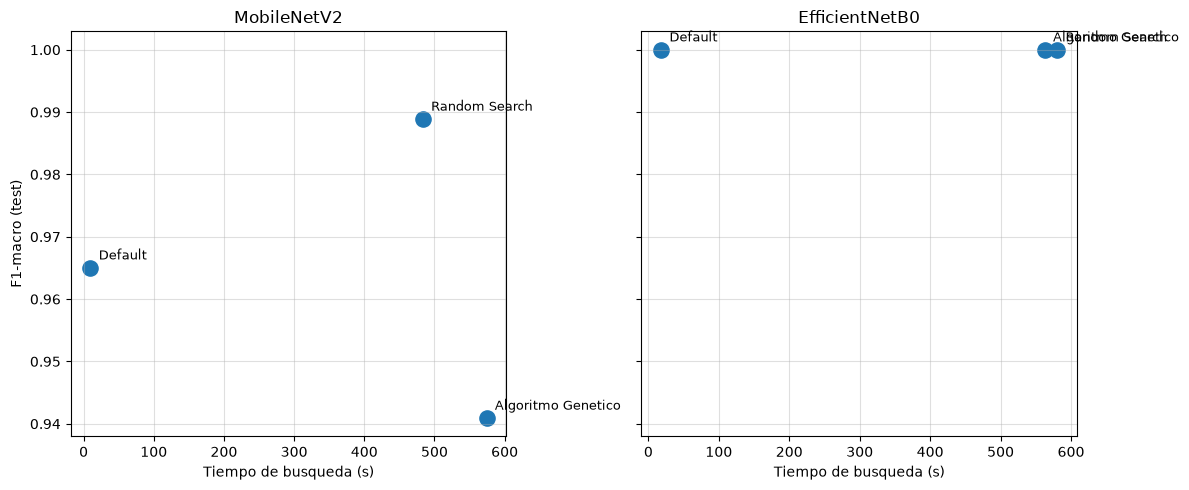

In [17]:
fig, axes = plt.subplots(1, len(BACKBONES), figsize=(6*len(BACKBONES), 5), sharey=True)
if len(BACKBONES) == 1:
    axes = [axes]

for ax, backbone in zip(axes, BACKBONES):
    res = all_results[backbone]
    strategies_plot = ["Algoritmo Genetico", "Random Search", "Default"]
    times_plot = [res["search_time"][s] for s in strategies_plot]
    f1_plot = [res["test_results"][s]["f1"] for s in strategies_plot]

    ax.scatter(times_plot, f1_plot, s=120)
    for s, t, f in zip(strategies_plot, times_plot, f1_plot):
        ax.annotate(s, (t, f), textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel("Tiempo de busqueda (s)")
    ax.set_title(backbone)
    ax.grid(True, alpha=0.4)

axes[0].set_ylabel("F1-macro (test)")
plt.tight_layout()
plt.show()

## 5. E4 — Comparativa con literatura
Compara el modelo ganador del E3 contra los resultados reportados en [3] y [4]. Completa los valores de referencia segun tus papers.

In [25]:
# TODO: reemplazar con los valores reportados en los papers [3] y [4]
literatura = {
    "[3] Autor et al.": {"accuracy": 0.992, "f1_macro": 0.992},
    "[4] Autor et al.": {"accuracy": 0.9904, "f1_macro": 0.9919},
}

best_test = all_results[best_backbone]["test_results"]["Algoritmo Genetico"]

e4_rows = [{"Fuente": f"Nuestro AG ({best_backbone})", "accuracy": best_test["acc"], "f1_macro": best_test["f1"]}]
for fuente, vals in literatura.items():
    e4_rows.append({"Fuente": fuente, **vals})

e4_df = pd.DataFrame(e4_rows)
e4_df

,Fuente,accuracy,f1_macro
0,Nuestro AG (EfficientNetB0),1.0000,1.0000
1,[3] Autor et al.,0.9920,0.9920
2,[4] Autor et al.,0.9904,0.9919


## 6. E5 — Curvas de convergencia (todas las arquitecturas en un solo grafico)

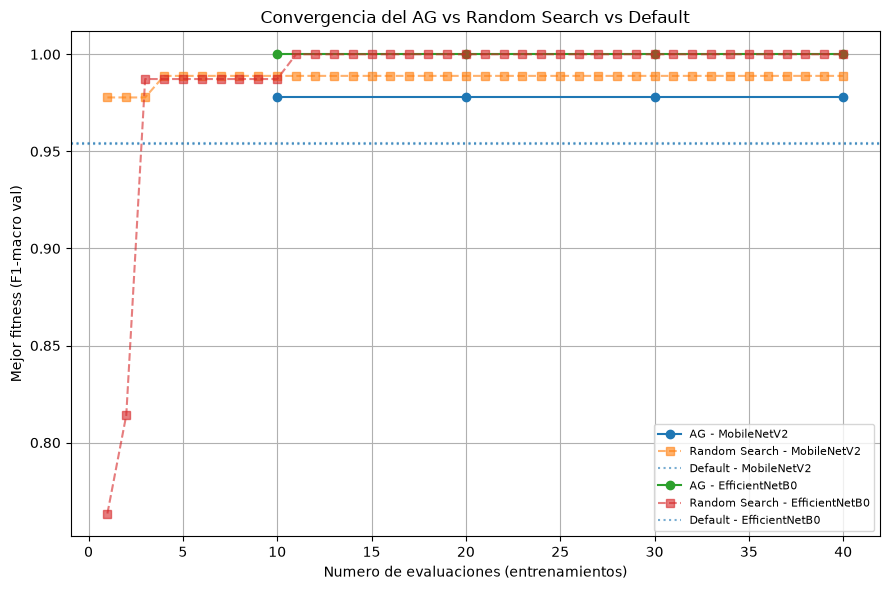

In [18]:
plt.figure(figsize=(9, 6))

for backbone, res in all_results.items():
    ag_curve, rs_curve = res["ag_curve"], res["rs_curve"]
    plt.plot(np.arange(1, len(ag_curve)+1) * ag.POP_SIZE, ag_curve, marker="o", label=f"AG - {backbone}")
    plt.plot(np.arange(1, len(rs_curve)+1), rs_curve, marker="s", alpha=0.6, linestyle="--", label=f"Random Search - {backbone}")
    plt.axhline(res["default"].fitness, ls=":", alpha=0.6, label=f"Default - {backbone}")

plt.xlabel("Numero de evaluaciones (entrenamientos)")
plt.ylabel("Mejor fitness (F1-macro val)")
plt.title("Convergencia del AG vs Random Search vs Default")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Matriz de confusion de la mejor estrategia global

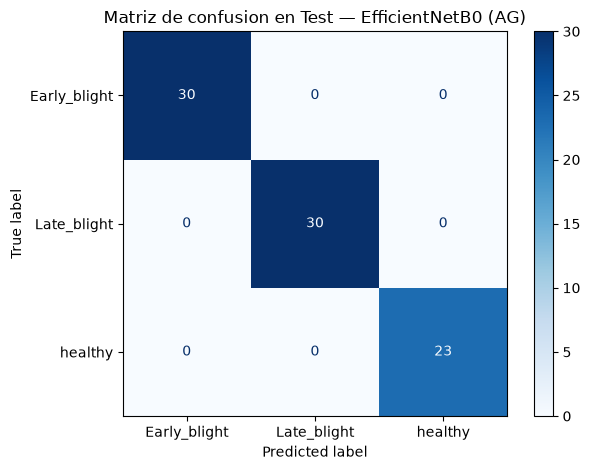

In [21]:
cm = confusion_matrix(y_test, all_results[best_backbone]["preds"]["Algoritmo Genetico"])
ConfusionMatrixDisplay(cm, display_labels=[c.replace("Potato___", "") for c in CLASS_NAMES]).plot(cmap="Blues")
plt.title(f"Matriz de confusion en Test — {best_backbone} (AG)")
plt.tight_layout()
plt.show()

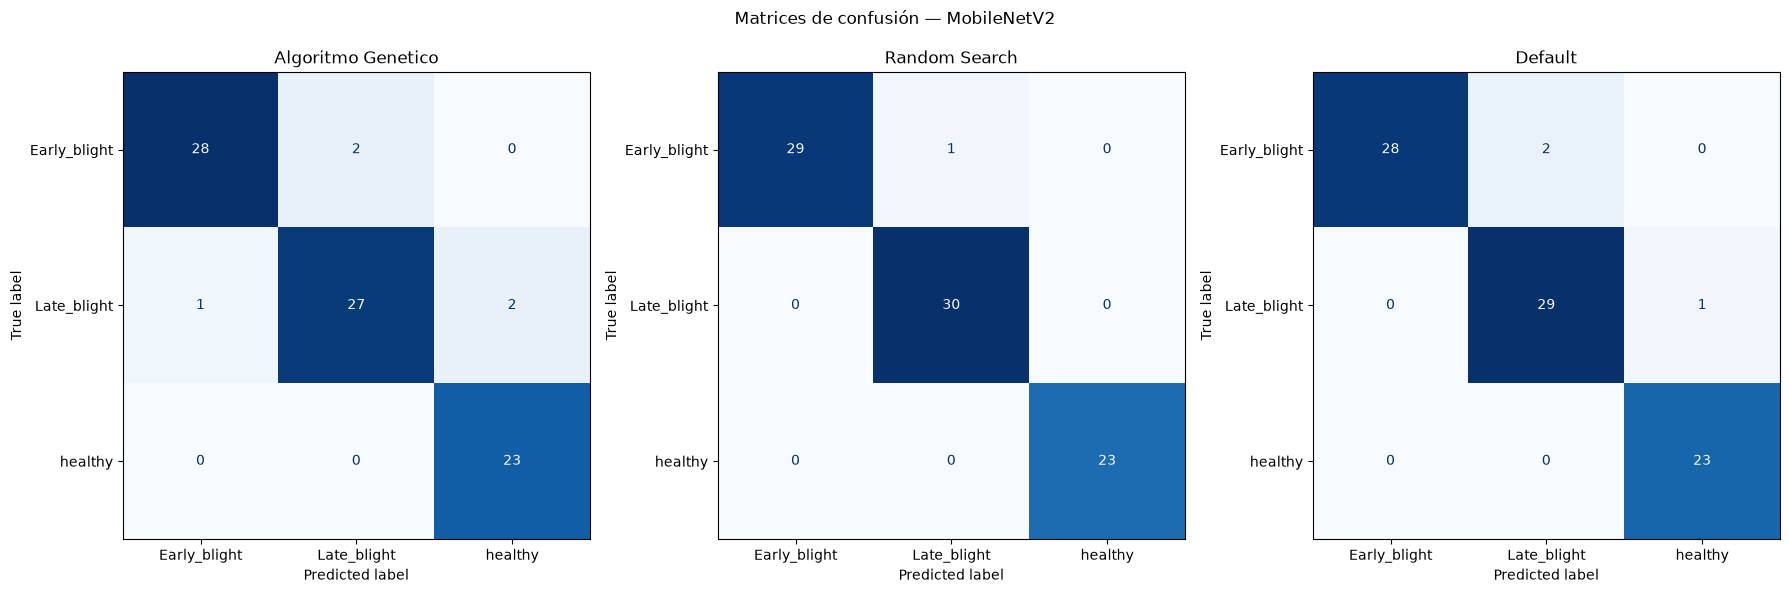

In [30]:
backbone = "MobileNetV2"
strategies = ["Algoritmo Genetico", "Random Search", "Default"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, strat in zip(axes, strategies):
    y_pred = all_results[backbone]["preds"][strat]
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[c.replace("Potato___", "") for c in CLASS_NAMES]).plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(strat)

plt.suptitle(f"Matrices de confusión — {backbone}")
plt.tight_layout()
plt.savefig(f"results/matrices_confusion_{backbone}_por_estrategia.png", dpi=160)
plt.show()

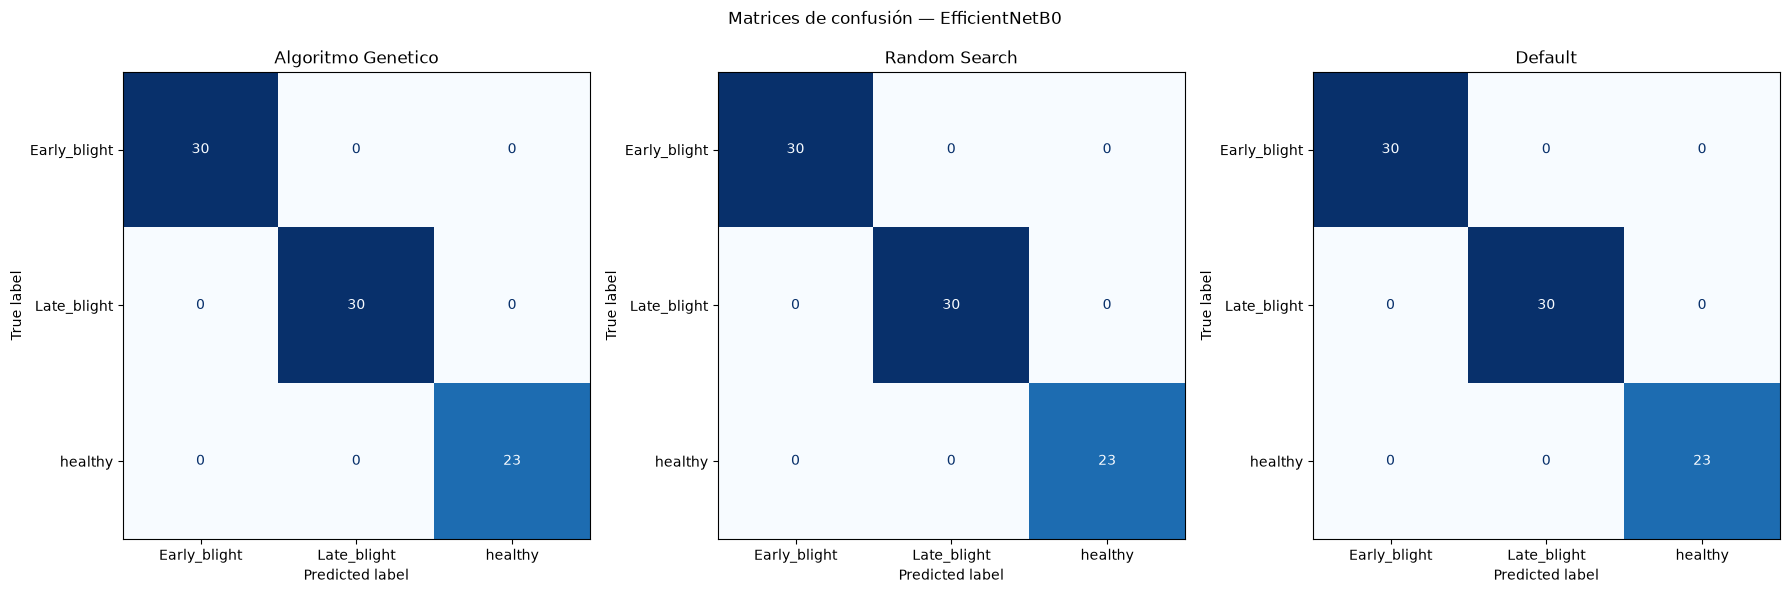

In [31]:
backbone = "EfficientNetB0"
strategies = ["Algoritmo Genetico", "Random Search", "Default"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, strat in zip(axes, strategies):
    y_pred = all_results[backbone]["preds"][strat]
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[c.replace("Potato___", "") for c in CLASS_NAMES]).plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(strat)

plt.suptitle(f"Matrices de confusión — {backbone}")
plt.tight_layout()
plt.savefig(f"results/matrices_confusion_{backbone}_por_estrategia.png", dpi=160)
plt.show()

In [ ]:
# Prueba para ver que no haya errores en el resultado de efficentnetB0
from sklearn.metrics import classification_report
print(classification_report(y_test, all_results["EfficientNetB0"]["preds"]["Algoritmo Genetico"], target_names=CLASS_NAMES))

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00        30
 Potato___Late_blight       1.00      1.00      1.00        30
     Potato___healthy       1.00      1.00      1.00        23

             accuracy                           1.00        83
            macro avg       1.00      1.00      1.00        83
         weighted avg       1.00      1.00      1.00        83



In [ ]:
# Prueba para validar diversidad en la generación inicial del AG
print(all_results["EfficientNetB0"]["ag_stats"][0])

{'gen': 0, 'best': 1.0, 'mean': 0.9123016235171828, 'std': 0.08534627322213423}


In [24]:
for seed_test in [42, 99, 7]:
    ag.configure(models={"EfficientNetB0": {"fn": keras.applications.EfficientNetB0, "preprocess": keras.applications.efficientnet.preprocess_input}}, n_class=N_CLASS, seed=seed_test, pop_size=10, gen_max=8, gen_pat=3, epochs_fitness=5, epochs_testeo=20)
    ag.clear_fitness_cache()
    np.random.seed(seed_test); random.seed(seed_test)
    population = ag.init_population(ag.POP_SIZE)
    best, curve, stats, t = ag.genetic_algo("EfficientNetB0", population, **fit_data)
    print(f"seed={seed_test} -> best gen0={stats[0]['best']:.4f}, mean gen0={stats[0]['mean']:.4f}, gen final donde llego a 1.0: {next((s['gen'] for s in stats if s['best']>=0.999), 'nunca')}")

alpha=6.43e-03 batch= 8 phi=rmsprop rho=0.14 | F1=0.9759  t= 21.2s
alpha=2.31e-03 batch= 8 phi=rmsprop rho=0.37 | F1=0.9759  t= 19.0s
alpha=5.50e-03 batch=64 phi=adam rho=0.01 | F1=0.9889  t=  8.8s
alpha=2.26e-03 batch= 8 phi=rmsprop rho=0.10 | F1=1.0000  t= 19.6s
alpha=6.53e-03 batch=64 phi=adam rho=0.22 | F1=0.9873  t=  8.5s
alpha=2.85e-03 batch= 8 phi=adam rho=0.35 | F1=0.9666  t= 19.2s
alpha=3.47e-03 batch=16 phi=adam rho=0.48 | F1=0.9889  t= 13.1s
alpha=3.43e-03 batch= 8 phi=sgd rho=0.05 | F1=0.9278  t= 20.7s
alpha=8.49e-03 batch=32 phi=adam rho=0.36 | F1=0.9759  t= 10.6s
alpha=5.41e-03 batch=64 phi=adam rho=0.28 | F1=1.0000  t=  9.5s
Poblacion inicial, mejor fitness = 1.0000
alpha=5.64e-03 batch=32 phi=adam rho=0.34 | F1=1.0000  t= 11.5s
alpha=8.26e-03 batch=64 phi=adam rho=0.30 | F1=0.9873  t=  9.8s
alpha=5.64e-03 batch= 8 phi=adam rho=0.26 | F1=1.0000  t= 19.4s
alpha=6.20e-03 batch=64 phi=rmsprop rho=0.16 | F1=0.9746  t=  8.6s
alpha=8.83e-03 batch=64 phi=adam rho=0.18 | F1=0.97

Resultados entre seeds:
- seed=42 -> best gen0=1.0000, mean gen0=0.9787, gen final donde llego a 1.0: 0
- seed=99 -> best gen0=0.9873, mean gen0=0.9210, gen final donde llego a 1.0: 1
- seed=7 -> best gen0=1.0000, mean gen0=0.9591, gen final donde llego a 1.0: 0

In [28]:
# Prueba con MobileNetV2 con seeds diferentes
for seed_test in [99, 20201497]:
    ag.configure(
        models={"MobileNetV2": {"fn": keras.applications.MobileNetV2, "preprocess": keras.applications.mobilenet_v2.preprocess_input}},
        n_class=N_CLASS, seed=seed_test, pop_size=10, gen_max=8, gen_pat=3, epochs_fitness=5, epochs_testeo=20,
    )
    ag.clear_fitness_cache()

    np.random.seed(seed_test); random.seed(seed_test)
    population = ag.init_population(ag.POP_SIZE)
    ag_best, ag_curve, ag_stats, _ = ag.genetic_algo("MobileNetV2", population, **fit_data)

    n_evals = ag.POP_SIZE * len(ag_curve)
    rs_best, rs_curve, _ = ag.random_search("MobileNetV2", n_evals, **fit_data)

    print(f"seed={seed_test} | AG best={ag_best.fitness:.4f}  RS best={rs_best.fitness:.4f}  diff={ag_best.fitness - rs_best.fitness:+.4f}")

alpha=4.10e-03 batch=16 phi=rmsprop rho=0.09 | F1=0.9667  t= 10.9s
alpha=2.56e-03 batch= 8 phi=sgd rho=0.36 | F1=0.9294  t= 14.8s
alpha=5.36e-03 batch= 8 phi=rmsprop rho=0.24 | F1=0.9889  t= 14.1s
alpha=4.27e-03 batch=16 phi=sgd rho=0.41 | F1=0.9197  t= 10.1s
alpha=8.63e-03 batch=16 phi=adam rho=0.23 | F1=0.9778  t= 11.3s
alpha=1.87e-03 batch=32 phi=adam rho=0.47 | F1=0.9667  t=  8.2s
alpha=5.33e-03 batch= 8 phi=sgd rho=0.16 | F1=0.9537  t= 14.6s
alpha=5.22e-04 batch= 8 phi=sgd rho=0.10 | F1=0.9034  t= 14.3s
alpha=9.90e-03 batch= 8 phi=sgd rho=0.26 | F1=0.9667  t= 14.1s
alpha=2.06e-03 batch=64 phi=adam rho=0.18 | F1=0.9303  t=  7.8s
Poblacion inicial, mejor fitness = 0.9889
alpha=8.32e-03 batch=16 phi=rmsprop rho=0.31 | F1=0.9778  t=  9.5s
alpha=5.66e-03 batch= 8 phi=adam rho=0.23 | F1=0.9667  t= 14.7s
alpha=4.79e-03 batch=64 phi=rmsprop rho=0.20 | F1=0.8705  t=  7.9s
alpha=5.35e-03 batch= 8 phi=adam rho=0.22 | F1=0.9889  t= 14.1s
alpha=7.98e-03 batch=16 phi=rmsprop rho=0.23 | F1=0.988

Resultados por seed:
- seed=99 | AG best=0.9889  RS best=0.9778  diff=+0.0111
- seed=20201497 | AG best=0.9778  RS best=0.9889  diff=-0.0111